In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches



Generation 1
Best fitness: 0.00017641102357204098, Average fitness: 0.00015595011773751204
Best Chromosome - Bins Used: 68, Space Wasted: 560058
End of generation

Generation 2
Best fitness: 0.00018637314139384746, Average fitness: 0.00016165115104918565
Best Chromosome - Bins Used: 65, Space Wasted: 530058
End of generation

Generation 3
Best fitness: 0.00018994867586778053, Average fitness: 0.00016388567892700794
Best Chromosome - Bins Used: 64, Space Wasted: 520058
End of generation

Generation 4
Best fitness: 0.00018994867586778053, Average fitness: 0.00016693055425444692
Best Chromosome - Bins Used: 64, Space Wasted: 520058
End of generation

Generation 5
Best fitness: 0.00018994867586778053, Average fitness: 0.00017151179261635732
Best Chromosome - Bins Used: 64, Space Wasted: 520058
End of generation

Generation 6
Best fitness: 0.00018994867586778053, Average fitness: 0.00017423530187010494
Best Chromosome - Bins Used: 64, Space Wasted: 520058
End of generation

Generation 7
Be

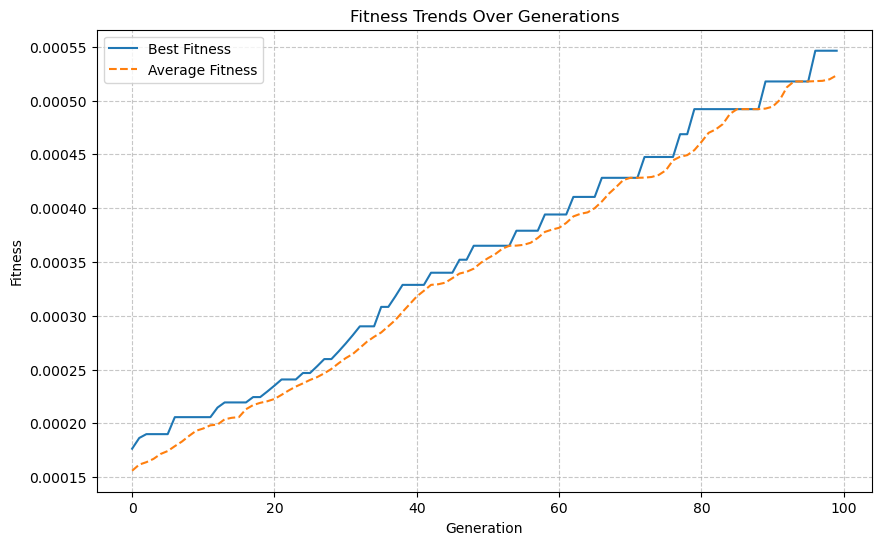

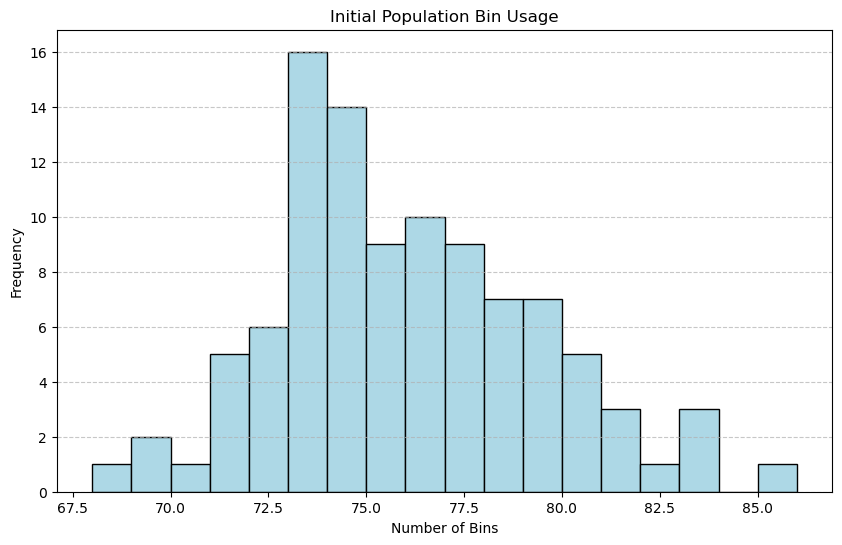

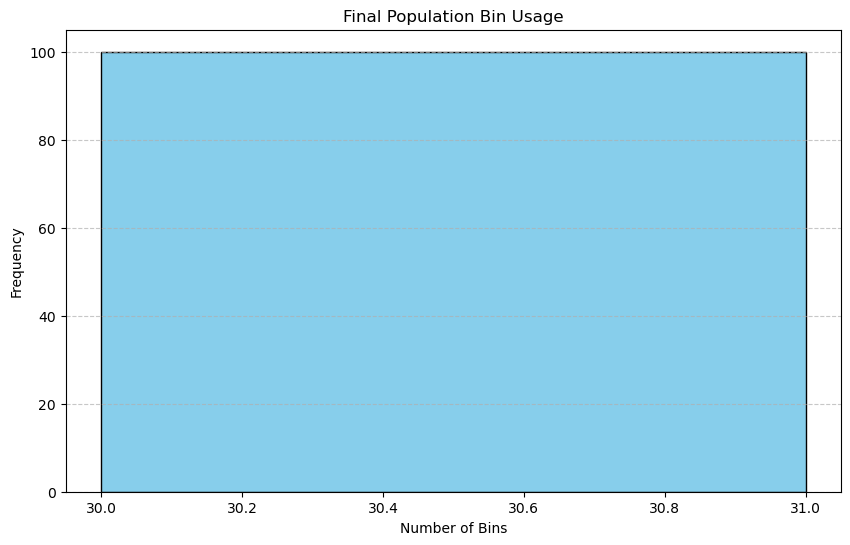

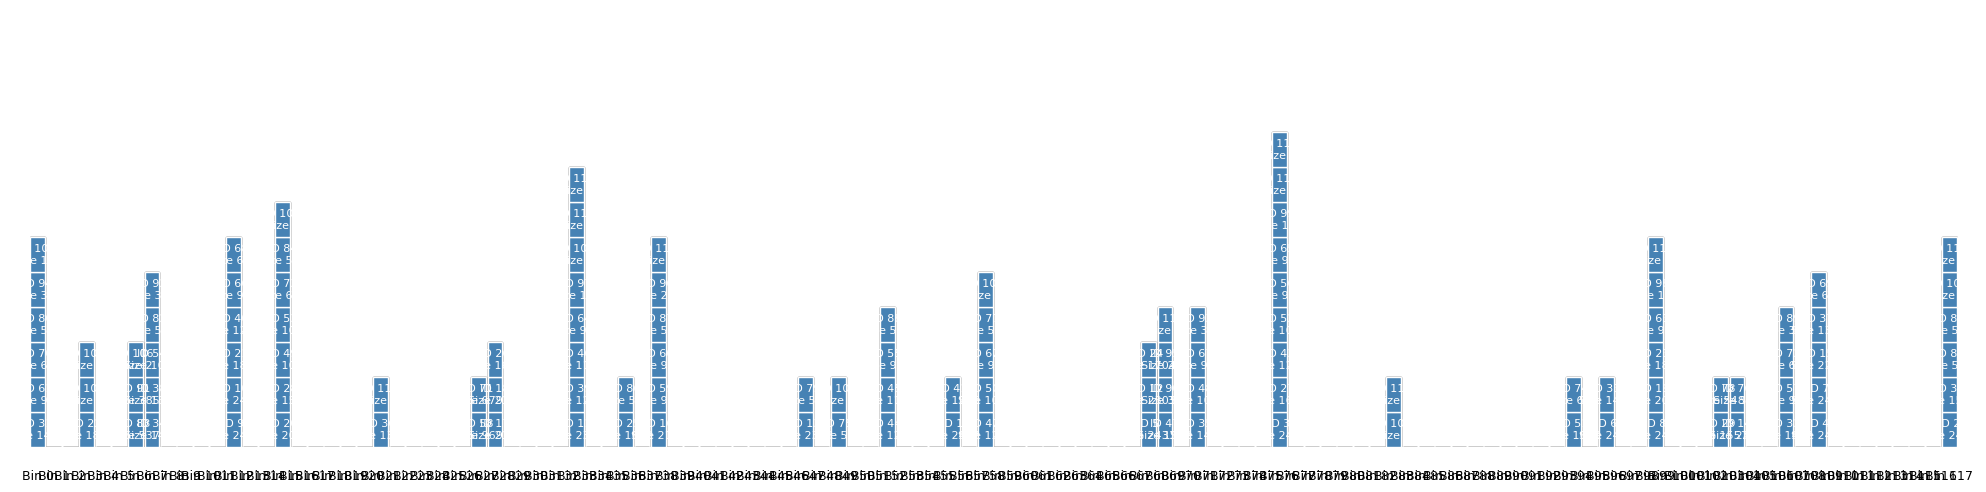

Final best fitness: 0.0005462749511083919
Final bins used: 30
Final space wasted: 180058


In [ ]:

class Chromosome:
    def __init__(self, items, bin_capacity, genes=None):
        self.items = items
        self.bin_capacity = bin_capacity
        self.genes = genes if genes else self._generate_random_chromosome()
        self.num_bins_used = 0
        self.space_wasted = 0
        self.fitness_score = 0
        self.calculate_fitness()

    def _generate_random_chromosome(self):
        genes = [-1] * len(self.items)
        bins = [[] for _ in range(len(self.items))]
        for i, item_size in enumerate(self.items):
            while True:
                bin_index = random.randint(0, len(self.items) - 1)
                if sum(bins[bin_index]) + item_size <= self.bin_capacity:
                    bins[bin_index].append(item_size)
                    genes[i] = bin_index
                    break
        return genes

    def calculate_fitness(self, alpha=0.01):
        bins = [[] for _ in range(max(self.genes) + 1)]
        for i, bin_index in enumerate(self.genes):
            bins[bin_index].append(self.items[i])
        self.num_bins_used = len([b for b in bins if sum(b) > 0])
        self.space_wasted = sum([self.bin_capacity - sum(b) for b in bins if sum(b) > 0])
        self.fitness_score = 1 / (self.num_bins_used + alpha * self.space_wasted)


class GAOperators:
    @staticmethod
    def tournament_selection(population, tournament_size):
        selected = []
        for _ in range(2):
            tournament = random.sample(population, tournament_size)
            best = max(tournament, key=lambda chromo: chromo.fitness_score)
            selected.append(best)
        return selected[0], selected[1]

    @staticmethod
    def one_point_crossover(parent1, parent2):
        crossover_point = random.randint(1, len(parent1.genes) - 1)
        child1_genes = parent1.genes[:crossover_point] + parent2.genes[crossover_point:]
        child2_genes = parent2.genes[:crossover_point] + parent1.genes[crossover_point:]
        return Chromosome(parent1.items, parent1.bin_capacity, GAOperators._validate(child1_genes, parent1.items, parent1.bin_capacity)), \
               Chromosome(parent2.items, parent2.bin_capacity, GAOperators._validate(child2_genes, parent2.items, parent2.bin_capacity))

    @staticmethod
    def _validate(genes, items, bin_capacity):
        bins = [[] for _ in range(max(genes) + 1)]
        for i, bin_index in enumerate(genes):
            bins[bin_index].append(i)
        
        corrected_genes = [-1] * len(genes)
        for bin_index, item_indices in enumerate(bins):
            current_bin_capacity = 0
            for item_index in item_indices:
                item_size = items[item_index]
                if current_bin_capacity + item_size <= bin_capacity:
                    current_bin_capacity += item_size
                    corrected_genes[item_index] = bin_index
                else:
                    for new_bin in range(len(bins)):
                        if new_bin != bin_index and sum(items[i] for i in bins[new_bin]) + item_size <= bin_capacity:
                            bins[new_bin].append(item_index)
                            corrected_genes[item_index] = new_bin
                            break
                    else:
                        new_bin_index = len(bins)
                        bins.append([item_index])
                        corrected_genes[item_index] = new_bin_index
        return corrected_genes

    @staticmethod
    def swap_mutation(chromosome):
        index1, index2 = random.sample(range(len(chromosome.genes)), 2)
        new_genes = chromosome.genes[:]
        new_genes[index1], new_genes[index2] = new_genes[index2], new_genes[index1]
        return Chromosome(chromosome.items, chromosome.bin_capacity, GAOperators._validate(new_genes, chromosome.items, chromosome.bin_capacity))


class BinPackingGA:
    def __init__(self, items, bin_capacity, pop_size=100, generations=100, mutation_rate=0.1, tournament_size=3, elite_percentage=0.01):
        self.items = items
        self.bin_capacity = bin_capacity
        self.pop_size = pop_size
        self.generations = generations
        self.mutation_rate = mutation_rate
        self.tournament_size = tournament_size
        self.elite_percentage = elite_percentage
        self.population = [Chromosome(items, bin_capacity) for _ in range(pop_size)]
        self.initial_bin_usage = [chromo.num_bins_used for chromo in self.population] 
        self.fitness_progress = []
        self.average_fitness_progress = []

    def run(self):
        for generation in range(self.generations):
            print(f"\nGeneration {generation + 1}")
            fitness_values = [chromo.fitness_score for chromo in self.population]
            best_chromosome = max(self.population, key=lambda chromo: chromo.fitness_score)
            best_fitness = best_chromosome.fitness_score
            average_fitness = sum(fitness_values) / len(fitness_values)
            self.fitness_progress.append(best_fitness)
            self.average_fitness_progress.append(average_fitness)

            print(f"Best fitness: {best_fitness}, Average fitness: {average_fitness}")
            print(f"Best Chromosome - Bins Used: {best_chromosome.num_bins_used}, Space Wasted: {best_chromosome.space_wasted}")

            new_population = self._create_new_population()
            self._apply_elitism(new_population)
            print("End of generation")

    def _create_new_population(self):
        new_population = []
        while len(new_population) < self.pop_size:
            parent1, parent2 = GAOperators.tournament_selection(self.population, self.tournament_size)
            child1, child2 = GAOperators.one_point_crossover(parent1, parent2)
            if random.random() < self.mutation_rate:
                child1 = GAOperators.swap_mutation(child1)
            if random.random() < self.mutation_rate:
                child2 = GAOperators.swap_mutation(child2)
            new_population.extend([child1, child2])
        return new_population

    def _apply_elitism(self, new_population):
        num_elites = max(1, int(self.pop_size * self.elite_percentage))
        elites = sorted(self.population, key=lambda chromo: chromo.fitness_score, reverse=True)[:num_elites]
        new_population.sort(key=lambda chromo: chromo.fitness_score)
        new_population[:num_elites] = elites
        self.population = new_population[:self.pop_size]

    def plot_fitness_trends(self):
      
        plt.figure(figsize=(10, 6))
        plt.plot(self.fitness_progress, label="Best Fitness")
        plt.plot(self.average_fitness_progress, label="Average Fitness", linestyle="--")
        plt.title("Fitness Trends Over Generations")
        plt.xlabel("Generation")
        plt.ylabel("Fitness")
        plt.legend()
        plt.grid(axis='both', linestyle='--', alpha=0.7)
        plt.show()

    def plot_histogram_of_bins(self):
        plt.figure(figsize=(10, 6))
        plt.hist(self.initial_bin_usage, bins=range(min(self.initial_bin_usage), max(self.initial_bin_usage) + 1), color='lightblue', edgecolor='black')
        plt.title("Initial Population Bin Usage")
        plt.xlabel("Number of Bins")
        plt.ylabel("Frequency")
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()

        final_bin_usage = [chromo.num_bins_used for chromo in self.population if chromo.num_bins_used > 0]
        plt.figure(figsize=(10, 6))
        plt.hist(final_bin_usage, bins=range(min(final_bin_usage), max(final_bin_usage) + 1), color='skyblue', edgecolor='black')
        plt.title("Final Population Bin Usage")
        plt.xlabel("Number of Bins")
        plt.ylabel("Frequency")
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()

    def plot_bins_like_image(self, chromosome):
        bins = [[] for _ in range(max(chromosome.genes) + 1)]
        for i, bin_index in enumerate(chromosome.genes):
            bins[bin_index].append((i + 1, self.items[i]))

        fig, ax = plt.subplots(figsize=(20, 5))
        ax.set_xlim(0, len(bins))
        ax.set_ylim(0, max(len(items) for items in bins) + 1)
        ax.axis('off')

        bin_width = 0.9
        item_height = 0.8

        for bin_index, items in enumerate(bins):
            rect = patches.Rectangle((bin_index, 0), bin_width, len(items) * item_height, linewidth=1, edgecolor='black', facecolor='lightgray')
            ax.add_patch(rect)

            for item_index, (item_number, item_size) in enumerate(items):
                item_rect = patches.Rectangle((bin_index, item_index * item_height), bin_width, item_height, edgecolor='white', facecolor='steelblue')
                ax.add_patch(item_rect)
                ax.text(bin_index + bin_width / 2, item_index * item_height + item_height / 2,
                        f"ID {item_number}\nSize {item_size}", ha='center', va='center', fontsize=8, color='white')

        for bin_index in range(len(bins)):
            ax.text(bin_index + bin_width / 2, -0.5, f"Bin {bin_index}", ha='center', va='top', fontsize=9, color='black')

        plt.tight_layout()
        plt.show()

        with open('bin_values.txt', 'w') as file:
            for bin_index, items in enumerate(bins):
                file.write(f"Bin {bin_index}:\n")
                for item_number, item_size in items:
                    file.write(f"  Item {item_number} - Size: {item_size}\n")
                file.write("\n")

with open('5.txt', 'r') as file:
    lines = file.readlines()
NUM_ITEMS = int(lines[0].strip())
BIN_CAPACITY = int(lines[1].strip())
ITEM_SIZES = [int(size.strip()) for size in lines[2:]]

# Initialize and run GA
ga = BinPackingGA(items=ITEM_SIZES, bin_capacity=BIN_CAPACITY)
ga.run()
ga.plot_fitness_trends()

ga.plot_histogram_of_bins()

best_chromosome = max(ga.population, key=lambda chromo: chromo.fitness_score)
ga.plot_bins_like_image(best_chromosome)

# Print final result
print(f"Final best fitness: {best_chromosome.fitness_score}")
print(f"Final bins used: {best_chromosome.num_bins_used}")
print(f"Final space wasted: {best_chromosome.space_wasted}")
